Exploratory data analysis -> miss abstract and sometime authors -> merge by id since id unique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import sys
from pathlib import Path

# Add project root so notebook can import from src/
PROJECT_ROOT = Path("../").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_PATH_STAGE1, TEST_PATH_STAGE1
from src.utils.utils import load_csv, preview_df

train_df = load_csv(TRAIN_PATH_STAGE1)
test_df = load_csv(TEST_PATH_STAGE1)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train path:", TRAIN_PATH_STAGE1)
print("Test path:", TEST_PATH_STAGE1)

preview_df(train_df)

Train shape: (510, 7)
Test shape: (86, 6)
Train path: /Users/nhatnam/Documents/DM_252/Assignment/data/raw/Stage1/Stage_1_publcitrain.csv
Test path: /Users/nhatnam/Documents/DM_252/Assignment/data/raw/Stage1/test (2).csv
Shape: (510, 7)
Columns: ['title', 'venue', 'year', 'authors', 'doi', 'Label', 'id']


,title,venue,year,authors,doi,Label,id
0,Tabled CLP for Reasoning Over Stream Data.,iclp,2016,"Edmond Jajaga, Lule Ahmedi",10.1109/icsc.2017.64,1,299
1,"XAI-LAW: A Logic Programming Tool for Modeling, Explaining, and Learning Legal Decisions.",iclp,2025,"Agostino Dovier, Talissa Dreossi, Andrea Formisano, Benedetta Strizzolo",10.4204/eptcs.439.28,5,92
2,"Workshop Proceedings of the 40th International Conference on Logic Programming (ICLP-WS 2024) co-located with the 40th International Conference on Logic Programming (ICLP 2024), Dallas, TX, USA, O...",iclp,2024,"Esteban Guerrero, Juan Carlos Nieves",10.1007/978-3-031-74209-5_21,1,311
3,Probabilistic Active Goal Recognition.,kr,2025,"Chenyuan Zhang, Cristian Rojas Cardenas, Hamid Rezatofighi, Mor Vered, Buser Say",10.24963/kr.2025/85,5,136
4,Heuristic Strategies for Accelerating Multi-Agent Epistemic Planning.,kr,2024,"Biqing Fang, Fangzhen Lin",10.24963/kr.2024/32,1,41


In [3]:
print("===== TRAIN MISSING VALUES =====")
display(train_df.isnull().sum().to_frame("Missing Count"))

print("\n===== TEST MISSING VALUES =====")
display(test_df.isnull().sum().to_frame("Missing Count"))

===== TRAIN MISSING VALUES =====


,Missing Count
title,0
venue,0
year,0
authors,52
doi,0
Label,0
id,0



===== TEST MISSING VALUES =====


,Missing Count
title,0
venue,0
year,0
authors,8
doi,0
id,0


===== LABEL DISTRIBUTION =====


,Count
Label,
1,130
2,103
3,85
4,89
5,103


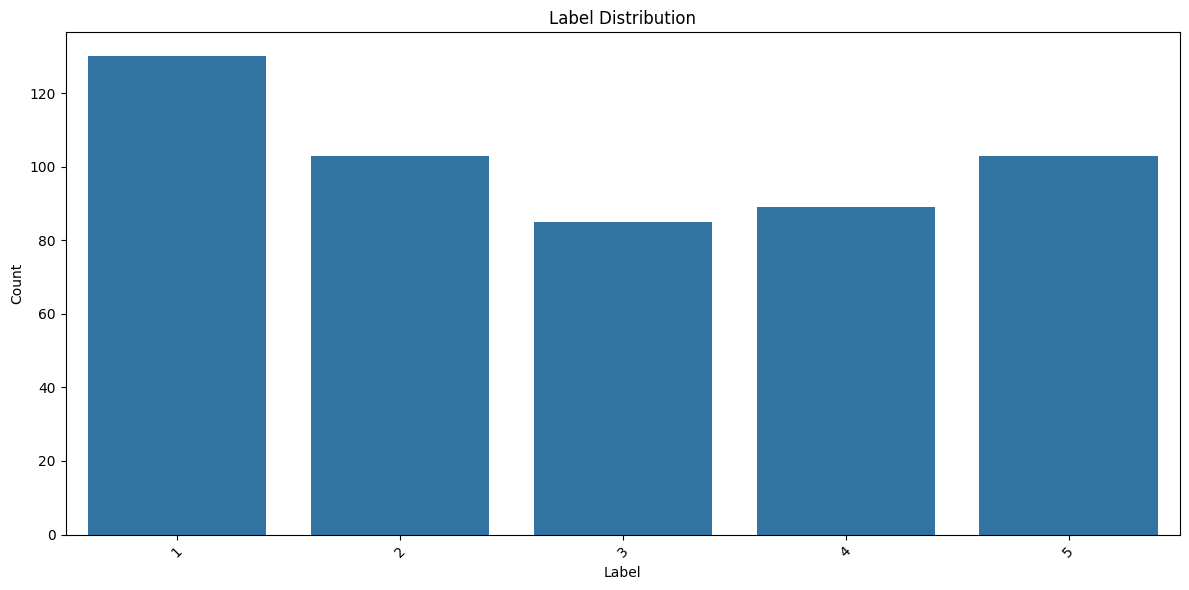

In [4]:
print("===== LABEL DISTRIBUTION =====")

label_counts = train_df["Label"].value_counts().sort_index()

display(label_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.countplot(
    data=train_df,
    x="Label",
    order=sorted(train_df["Label"].unique())
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
print("===== DUPLICATE CHECK : TRAIN =====")

print("Duplicate IDs:", train_df["id"].duplicated().sum())
print("Duplicate Titles:", train_df["title"].duplicated().sum())
print("Duplicate DOI:", train_df["doi"].duplicated().sum())
print("Duplicate Full Rows:", train_df.duplicated().sum())


print("\n===== DUPLICATE CHECK : TEST =====")

print("Duplicate IDs:", test_df["id"].duplicated().sum())
print("Duplicate Titles:", test_df["title"].duplicated().sum())
print("Duplicate DOI:", test_df["doi"].duplicated().sum())
print("Duplicate Full Rows:", test_df.duplicated().sum())

===== DUPLICATE CHECK : TRAIN =====
Duplicate IDs: 0
Duplicate Titles: 2
Duplicate DOI: 18
Duplicate Full Rows: 0

===== DUPLICATE CHECK : TEST =====
Duplicate IDs: 0
Duplicate Titles: 0
Duplicate DOI: 2
Duplicate Full Rows: 0


===== TOP VENUES : TRAIN =====


,Count
venue,
iclp,336
kr,174


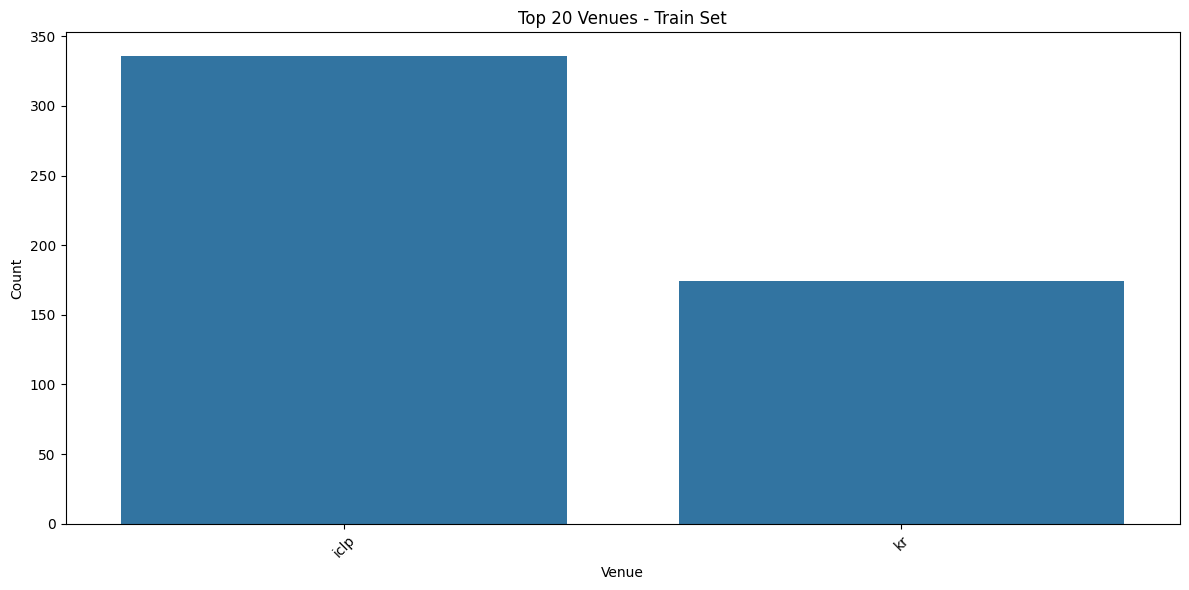

===== TOP VENUES : TEST =====


,Count
venue,
iclp,58
kr,28


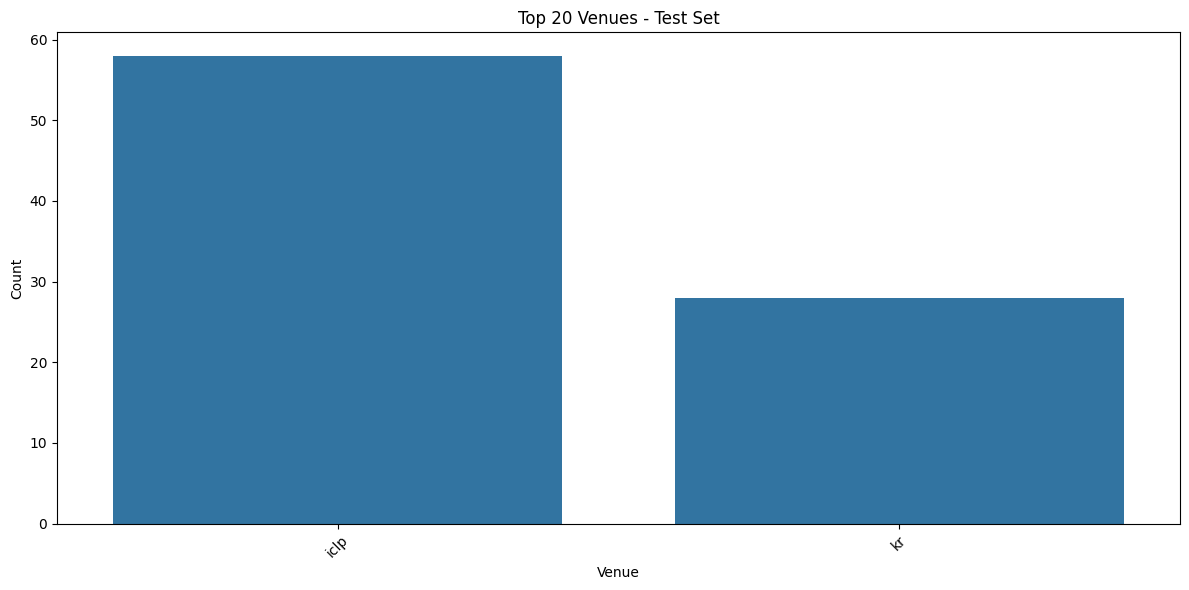

In [12]:
print("===== TOP VENUES : TRAIN =====")

train_venue_counts = train_df["venue"].value_counts().head(20)

display(train_venue_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=train_venue_counts.index,
    y=train_venue_counts.values
)

plt.title("Top 20 Venues - Train Set")
plt.xlabel("Venue")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("===== TOP VENUES : TEST =====")

test_venue_counts = test_df["venue"].value_counts().head(20)

display(test_venue_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=test_venue_counts.index,
    y=test_venue_counts.values
)

plt.title("Top 20 Venues - Test Set")
plt.xlabel("Venue")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

===== YEAR DISTRIBUTION : TRAIN =====


,Count
year,
2016,17
2017,10
2018,18
2019,28
2020,33
2021,36
2022,33
2023,88
2024,117


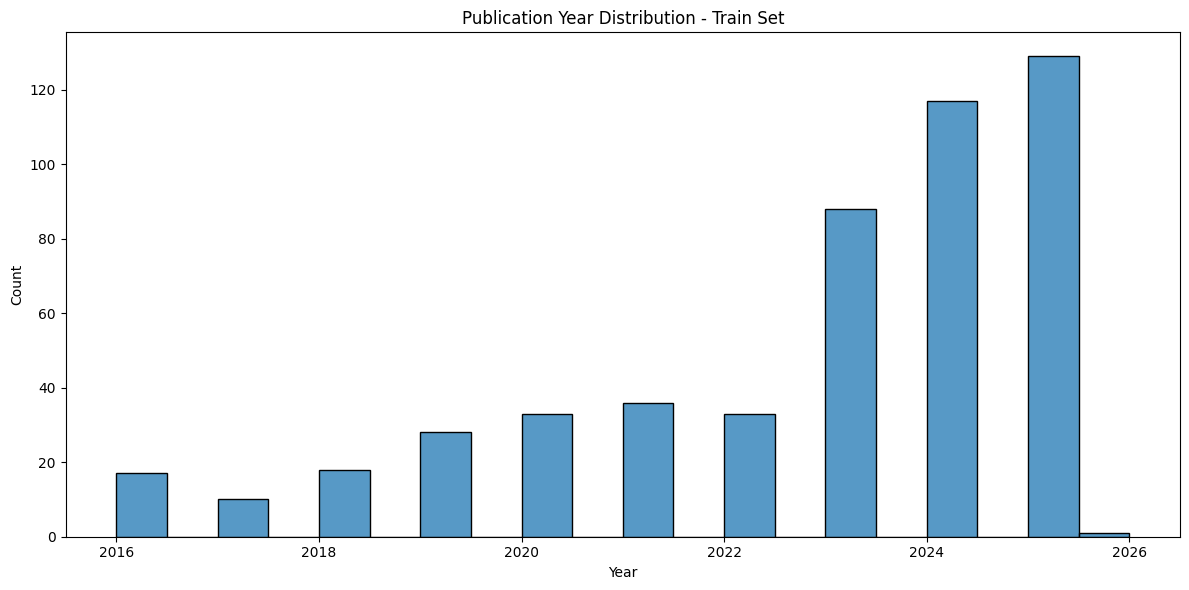

===== YEAR DISTRIBUTION : TEST =====


,Count
year,
2016,5
2017,4
2018,4
2019,4
2020,3
2021,12
2022,4
2023,12
2024,18


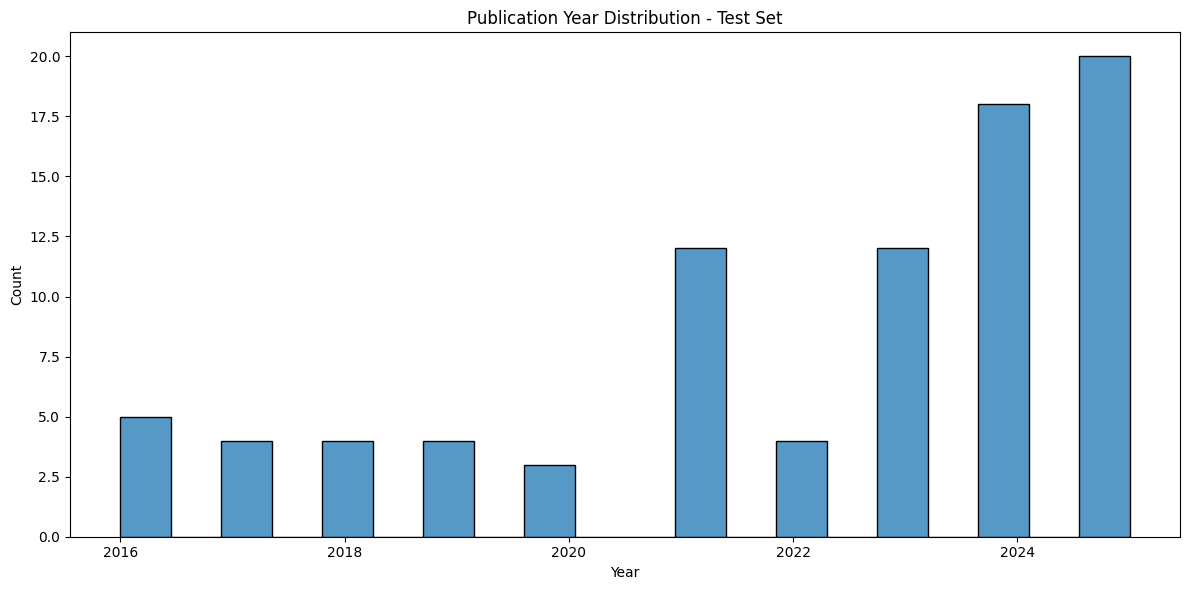

In [13]:
print("===== YEAR DISTRIBUTION : TRAIN =====")

train_year_counts = train_df["year"].value_counts().sort_index()

display(train_year_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.histplot(train_df["year"], bins=20)

plt.title("Publication Year Distribution - Train Set")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


print("===== YEAR DISTRIBUTION : TEST =====")

test_year_counts = test_df["year"].value_counts().sort_index()

display(test_year_counts.to_frame("Count"))

plt.figure(figsize=(12, 6))
sns.histplot(test_df["year"], bins=20)

plt.title("Publication Year Distribution - Test Set")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

===== NUMBER OF AUTHORS =====


count    510.000000
mean       2.539216
std        1.726208
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       18.000000
Name: num_authors, dtype: float64

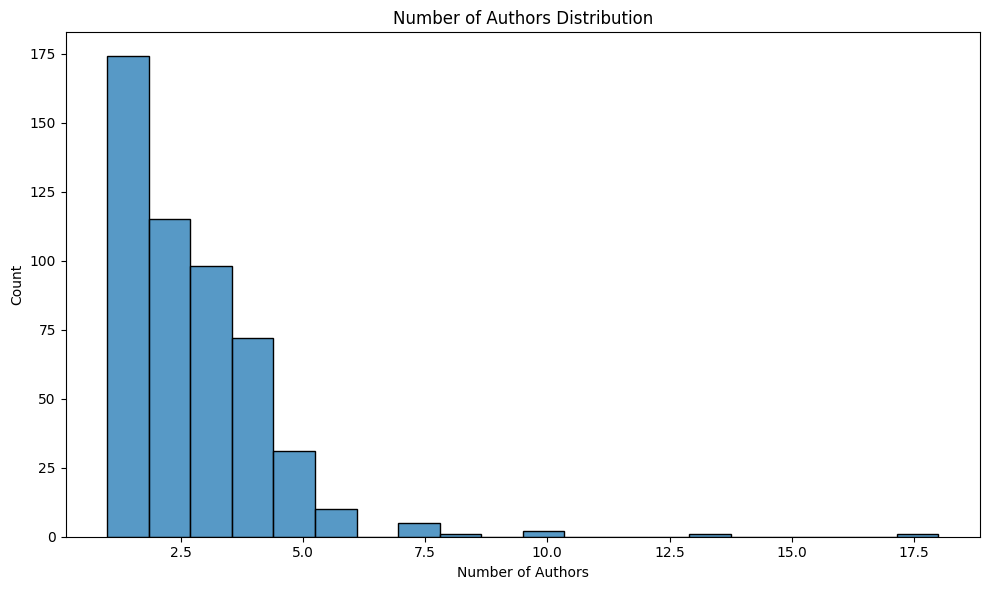

In [9]:
train_df["num_authors"] = train_df["authors"].apply(
    lambda x: len(str(x).split(","))
)

print("===== NUMBER OF AUTHORS =====")

display(train_df["num_authors"].describe())

plt.figure(figsize=(10, 6))
sns.histplot(train_df["num_authors"], bins=20)

plt.title("Number of Authors Distribution")
plt.xlabel("Number of Authors")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [14]:
print("===== DUPLICATE ID CHECK : TRAIN =====")

train_duplicate_id_count = train_df["id"].duplicated().sum()

print(f"Duplicate IDs in train set: {train_duplicate_id_count}")

if train_duplicate_id_count > 0:
    display(
        train_df[
            train_df["id"].duplicated(keep=False)
        ].sort_values("id")
    )
else:
    print("No duplicate IDs found in train set.")


print("\n===== DUPLICATE ID CHECK : TEST =====")

test_duplicate_id_count = test_df["id"].duplicated().sum()

print(f"Duplicate IDs in test set: {test_duplicate_id_count}")

if test_duplicate_id_count > 0:
    display(
        test_df[
            test_df["id"].duplicated(keep=False)
        ].sort_values("id")
    )
else:
    print("No duplicate IDs found in test set.")

===== DUPLICATE ID CHECK : TRAIN =====
Duplicate IDs in train set: 0
No duplicate IDs found in train set.

===== DUPLICATE ID CHECK : TEST =====
Duplicate IDs in test set: 0
No duplicate IDs found in test set.
